<h2 align=center>Exploratory Data Analysis With Python and Pandas</h2>
<img src="logo.png">

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot') 
sns.set_palette("viridis")
%matplotlib inline

Link to data source: https://www.kaggle.com/aungpyaeap/supermarket-sales

**Context**

The growth of supermarkets in most populated cities are increasing and market competitions are also high. The dataset is one of the historical sales of supermarket company which has recorded in 3 different branches for 3 months data.

**Data Dictionary**

1. ***Invoice id:*** Computer generated sales slip invoice identification number

2. ***Branch:*** Branch of supercenter (3 branches are available identified by A, B and C).

3. ***City:*** Location of supercenters

4. ***Customer type:*** Type of customers, recorded by Members for customers using member card and Normal for without member card.

5. ***Gender:*** Gender type of customer

6. ***Product line:*** General item categorization groups - Electronic accessories, Fashion accessories, Food and beverages, Health and beauty, Home and lifestyle, Sports and travel

7. ***Unit price:*** Price of each product in USD

8. ***Quantity:*** Number of products purchased by customer

9. ***Tax:*** 5% tax fee for customer buying

10. ***Total:*** Total price including tax

11. ***Date:*** Date of purchase (Record available from January 2019 to March 2019)

12. ***Time:*** Purchase time (10am to 9pm)

13. ***Payment:*** Payment used by customer for purchase (3 methods are available – Cash, Credit card and Ewallet)

14. ***COGS:*** Cost of goods sold

15. ***Gross margin percentage:*** Gross margin percentage

16. ***Gross income:*** Gross income

17. ***Rating:*** Customer stratification rating on their overall shopping experience (On a scale of 1 to 10)

### Task 1: Initial Data Exploration

In [2]:
df = pd.read_csv('supermarket_sales.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1003 non-null   object 
 1   Branch                   1003 non-null   object 
 2   City                     1003 non-null   object 
 3   Customer type            924 non-null    object 
 4   Gender                   1003 non-null   object 
 5   Product line             960 non-null    object 
 6   Unit price               996 non-null    float64
 7   Quantity                 983 non-null    float64
 8   Tax 5%                   1003 non-null   float64
 9   Total                    1003 non-null   float64
 10  Date                     1003 non-null   object 
 11  Time                     1003 non-null   object 
 12  Payment                  1003 non-null   object 
 13  cogs                     1003 non-null   float64
 14  gross margin percentage 

In [3]:
# Convert Date and Time to datetime objects immediately
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])

# Quick look at the Dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1003 non-null   object        
 1   Branch                   1003 non-null   object        
 2   City                     1003 non-null   object        
 3   Customer type            924 non-null    object        
 4   Gender                   1003 non-null   object        
 5   Product line             960 non-null    object        
 6   Unit price               996 non-null    float64       
 7   Quantity                 983 non-null    float64       
 8   Tax 5%                   1003 non-null   float64       
 9   Total                    1003 non-null   float64       
 10  Date                     1003 non-null   datetime64[ns]
 11  Time                     1003 non-null   datetime64[ns]
 12  Payment                  1003 non-

In [4]:
# Check for duplicate rows and missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(f"Total duplicates: {df.duplicated().sum()}")


--- Missing Values ---
Invoice ID                  0
Branch                      0
City                        0
Customer type              79
Gender                      0
Product line               43
Unit price                  7
Quantity                   20
Tax 5%                      0
Total                       0
Date                        0
Time                        0
Payment                     0
cogs                        0
gross margin percentage     0
gross income                0
Rating                      0
dtype: int64

--- Duplicate Rows ---
Total duplicates: 3


In [5]:
# Drop rows with missing values
df.dropna(inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

In [6]:
# Check column names
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [7]:
# Quick look at the numbers
df.describe()

,Unit price,Quantity,Tax 5%,Total,Date,Time,cogs,gross margin percentage,gross income,Rating
count,864.000000,864.000000,864.000000,864.000000,864,864,864.000000,864.000000,864.000000,864.000000
mean,55.636319,5.589120,15.688092,329.449932,2019-02-14 12:09:59.999999744,2026-03-11 15:30:06.041666560,313.761840,4.761905,15.688092,6.996759
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,2026-03-11 10:00:00,10.170000,4.761905,0.508500,4.000000
25%,33.245000,3.000000,6.277250,131.822250,2019-01-25 00:00:00,2026-03-11 12:46:00,125.545000,4.761905,6.277250,5.600000
50%,54.795000,6.000000,12.404000,260.484000,2019-02-14 00:00:00,2026-03-11 15:27:30,248.080000,4.761905,12.404000,7.000000
75%,77.935000,8.000000,23.091000,484.911000,2019-03-08 00:00:00,2026-03-11 18:22:00,461.820000,4.761905,23.091000,8.500000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,2026-03-11 20:59:00,993.000000,4.761905,49.650000,10.000000
std,26.409550,2.902657,11.811299,248.037276,NaN,NaN,236.225977,0.000000,11.811299,1.719741


In [8]:
# Reset index
df.reset_index(drop=True, inplace=True)

# Set Date column as index
df.set_index('Date', inplace =True)

### Task 2: Univariate Analysis

Rating Distribution

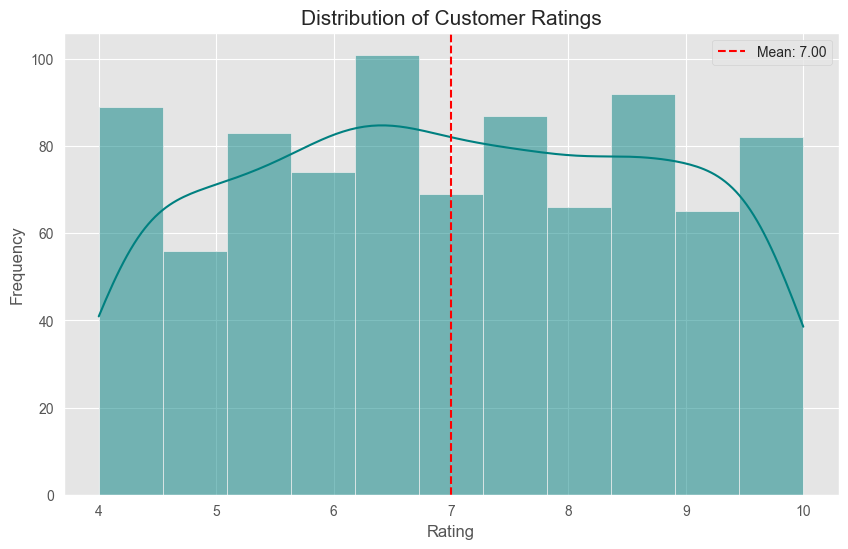

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], kde=True, color='teal')
plt.axvline(x=df['Rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["Rating"].mean():.2f}')

plt.title('Distribution of Customer Ratings', fontsize=15)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

Total Sales by Product Line

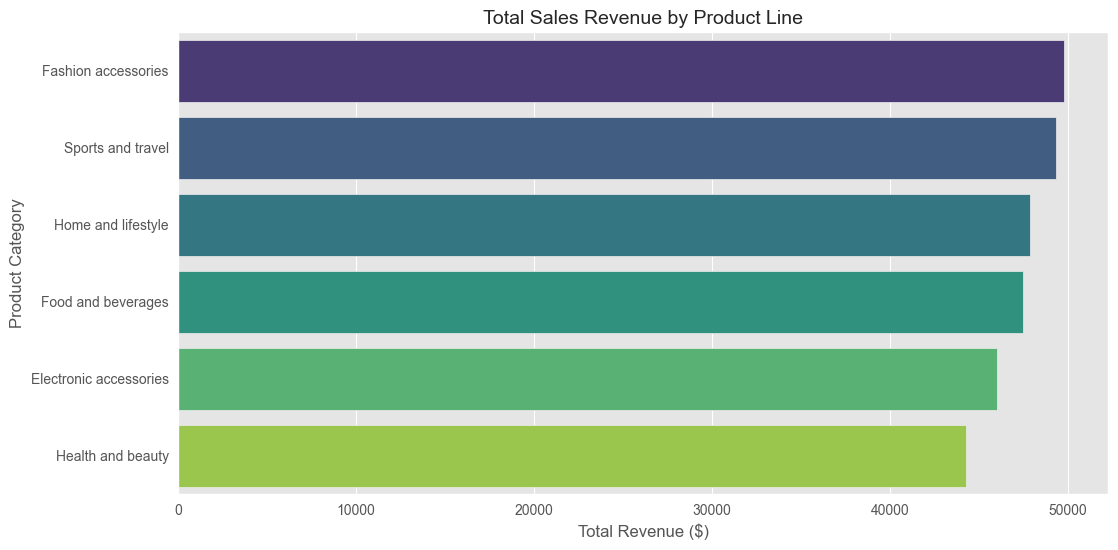

In [10]:
plt.figure(figsize=(12, 6))
product_sales = df.groupby('Product line')['Total'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=product_sales, x='Total', y='Product line', palette='viridis')

plt.title('Total Sales Revenue by Product Line', fontsize=14)
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Category')
plt.show()

Branch Performance by Gender

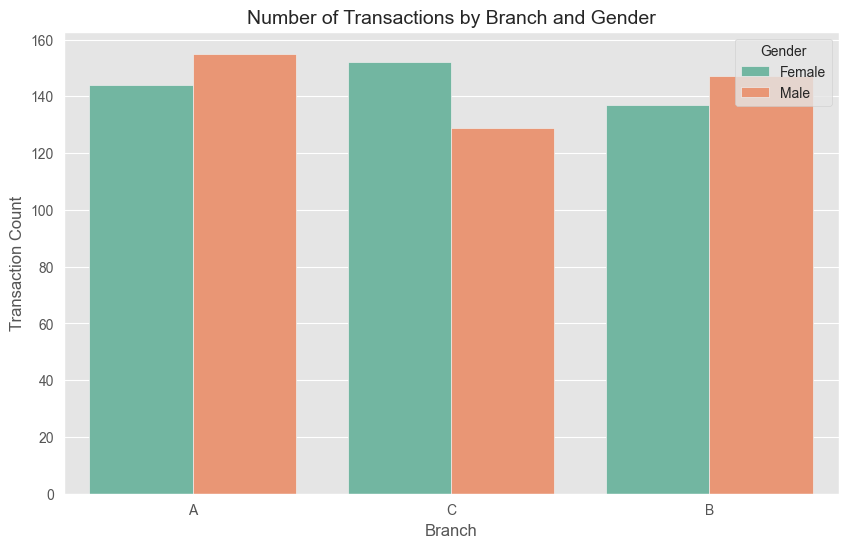

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Branch', hue='Gender', palette='Set2')

plt.title('Number of Transactions by Branch and Gender', fontsize=14)
plt.xlabel('Branch')
plt.ylabel('Transaction Count')
plt.show()

Sales Trend Over Time

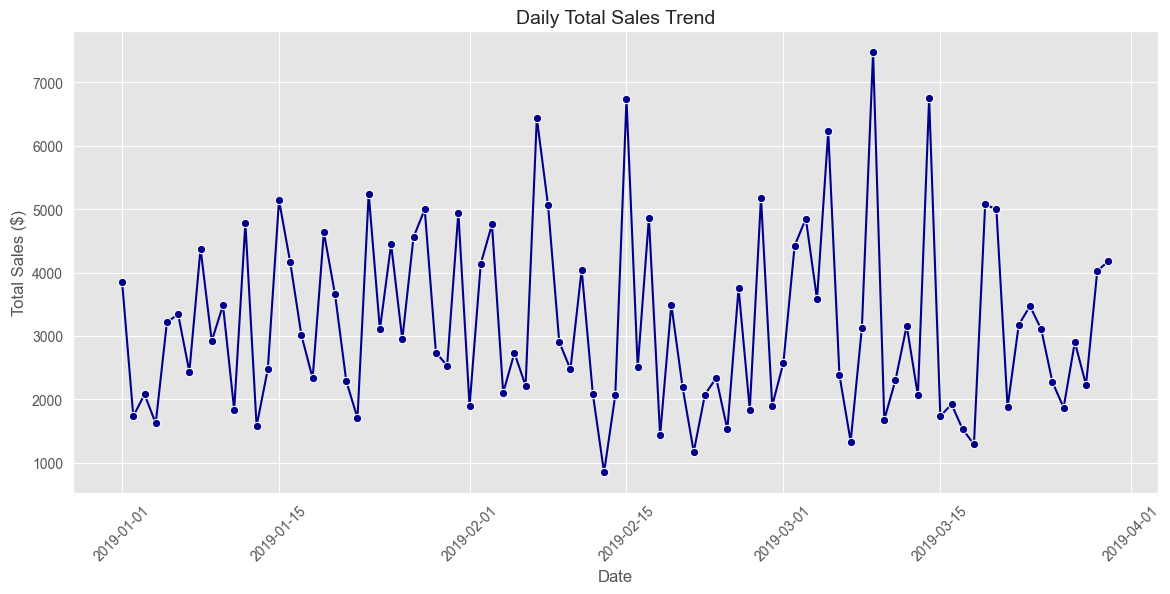

In [12]:
plt.figure(figsize=(14, 6))
daily_sales = df.groupby('Date')['Total'].sum().reset_index()
sns.lineplot(data=daily_sales, x='Date', y='Total', color='darkblue', marker='o')

plt.title('Daily Total Sales Trend', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.show()

Payment Method Distribution

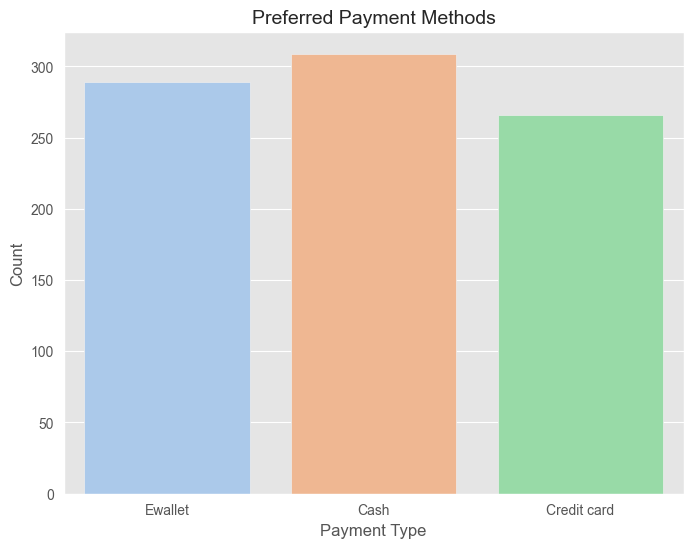

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Payment', palette='pastel')

plt.title('Preferred Payment Methods', fontsize=14)
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.show()

Sales by Customer Type

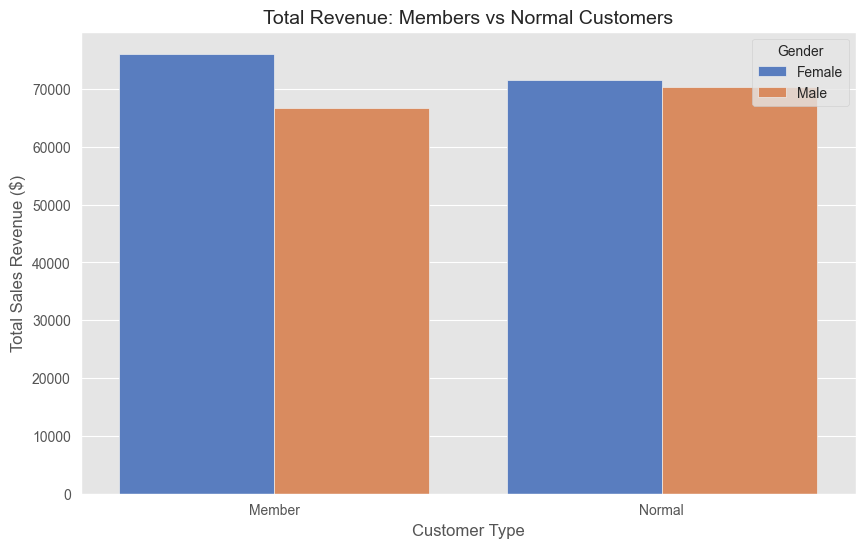

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Customer type', y='Total', hue='Gender', estimator=sum, errorbar=None, palette='muted')

plt.title('Total Revenue: Members vs Normal Customers', fontsize=14)
plt.xlabel('Customer Type')
plt.ylabel('Total Sales Revenue ($)')
plt.show()

### Task 3: Bivariate Analysis

Gross Income Distribution per Product Line

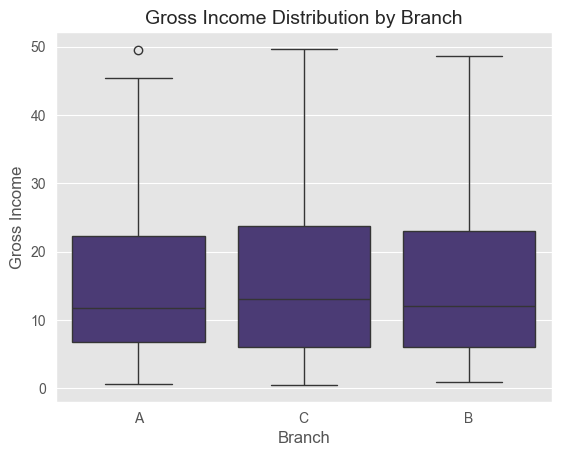

In [15]:
sns.boxplot(x=df['Branch'], y=df['gross income'])
plt.xlabel('Branch', fontsize=12)
plt.ylabel('Gross Income', fontsize=12)
plt.title('Gross Income Distribution by Branch', fontsize=14)
plt.show()

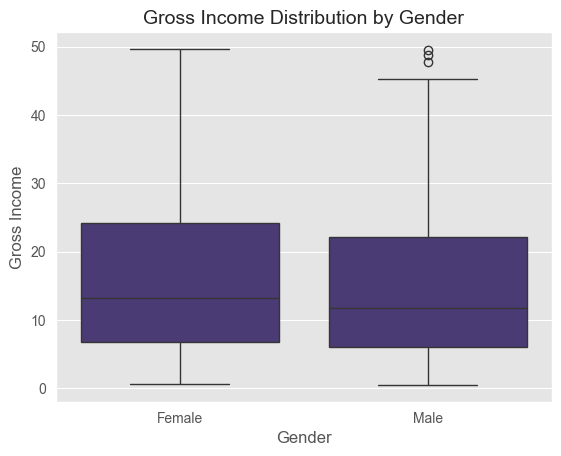

In [16]:
sns.boxplot(x=df['Gender'], y=df['gross income'])
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Gross Income', fontsize=12)
plt.title('Gross Income Distribution by Gender', fontsize=14)
plt.show()

In [17]:
df.groupby(df.index).mean(numeric_only=True).index

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-01-05', '2019-01-06', '2019-01-07', '2019-01-08',
               '2019-01-09', '2019-01-10', '2019-01-11', '2019-01-12',
               '2019-01-13', '2019-01-14', '2019-01-15', '2019-01-16',
               '2019-01-17', '2019-01-18', '2019-01-19', '2019-01-20',
               '2019-01-21', '2019-01-22', '2019-01-23', '2019-01-24',
               '2019-01-25', '2019-01-26', '2019-01-27', '2019-01-28',
               '2019-01-29', '2019-01-30', '2019-01-31', '2019-02-01',
               '2019-02-02', '2019-02-03', '2019-02-04', '2019-02-05',
               '2019-02-06', '2019-02-07', '2019-02-08', '2019-02-09',
               '2019-02-10', '2019-02-11', '2019-02-12', '2019-02-13',
               '2019-02-14', '2019-02-15', '2019-02-16', '2019-02-17',
               '2019-02-18', '2019-02-19', '2019-02-20', '2019-02-21',
               '2019-02-22', '2019-02-23', '2019-02-24', '2019-02-25',
      

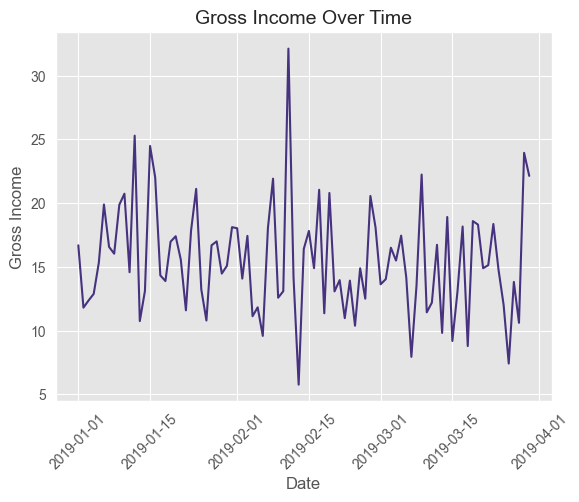

In [18]:
daily = df.groupby(df.index)['gross income'].mean()
sns.lineplot(x=daily.index, y=daily.values)
plt.xlabel('Date', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Gross Income', fontsize=12)
plt.title('Gross Income Over Time', fontsize=14)
plt.show()


Correlation Matrix Heatmap

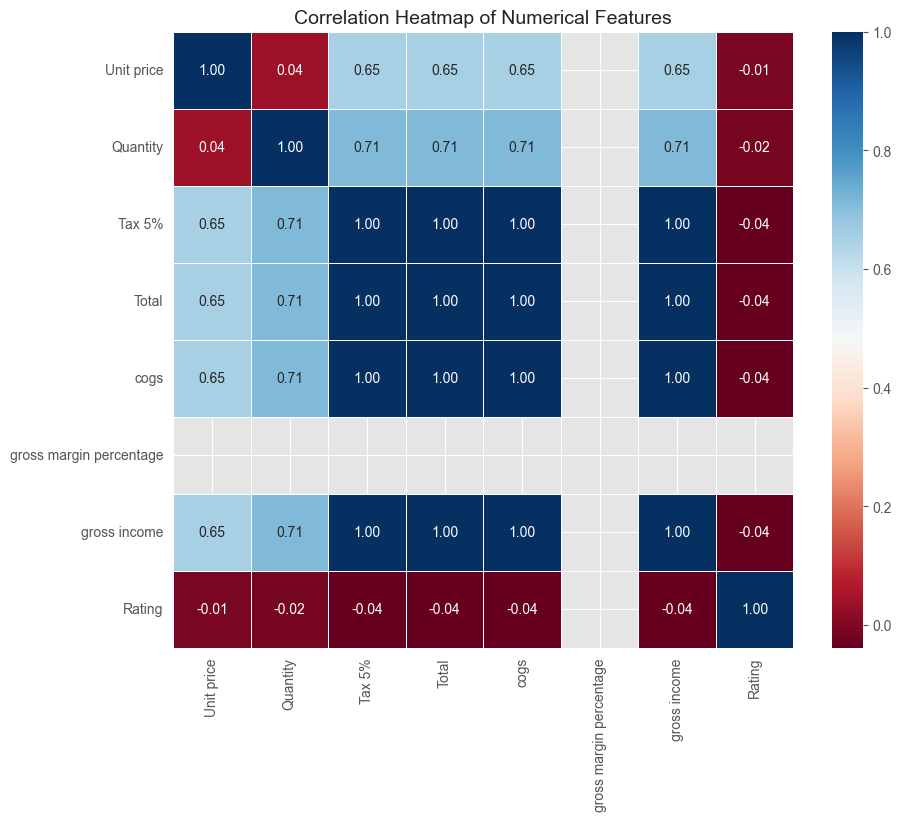

In [19]:
plt.figure(figsize=(10, 8))
# Filter numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

### Helpful Links

1. More visualizations: https://www.data-to-viz.com/
2. Seaborn gallery: https://seaborn.pydata.org/examples/index.html
3. Pandas profiling documentation: https://pypi.org/project/pandas-profiling/